In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar CSV
df = pd.read_csv("server_logs.csv")

# Ver estructura

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5795 entries, 0 to 5794
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   timestamp_event  5795 non-null   str  
 1   received_at      5795 non-null   str  
 2   service_name     5795 non-null   str  
 3   severity         5795 non-null   str  
 4   message          5795 non-null   str  
 5   trace_id         5795 non-null   str  
 6   request_id       5795 non-null   str  
 7   method           5795 non-null   str  
 8   endpoint         5795 non-null   str  
 9   status_code      5795 non-null   int64
 10  latency_ms       5795 non-null   int64
 11  host             5795 non-null   str  
 12  env              5795 non-null   str  
 13  region           5795 non-null   str  
 14  log_type         5795 non-null   str  
dtypes: int64(2), str(13)
memory usage: 679.2 KB


In [ ]:
df.head()

In [19]:
df['timestamp_event'] = pd.to_datetime(df['timestamp_event'], errors='coerce')
df['window'] = df['timestamp_event'].dt.floor('5min')
df['is_bad'] = (
     (df['severity'].isin(['ERROR', 'CRITICAL'])) |
    (df['status_code'] >= 500)
                )

print(df['window'].dtype)

datetime64[us, UTC]


que es series 

## 3. Exploración inicial

In [20]:
total_logs = len(df) # Cuenta cuántas filas hay en total.
sev_counts = df['severity'].value_counts() 
service_counts = df['service_name'].value_counts()
top_message = df['message'].value_counts().head(1)
top_bad_message = df[df['is_bad']]['message'].value_counts().head(1)

print(f'total de logs {total_logs}')


total de logs 5795


In [21]:
pd.DataFrame(sev_counts)

# print(sev_counts)

,count
severity,
INFO,3542
WARN,1358
ERROR,775
CRITICAL,120


In [22]:
pd.DataFrame(service_counts.head())


,count
service_name,
api-gateway,1509
orders-service,1057
inventory-service,964
payment-service,842
auth-service,778


In [23]:
pd.DataFrame(top_message)


,count
message,
Health check OK,1196


In [24]:
pd.DataFrame(top_bad_message)

,count
message,
Order creation failed - inventory lock timeout,197


## 4. Detección del momento crítico

In [25]:
window_stats = df.groupby('window').agg(
    total_events=('is_bad', 'count'),
    bad_events=('is_bad', 'sum')
)
window_stats['bad_rate'] = window_stats['bad_events'] / window_stats['total_events']
window_stats = window_stats[window_stats['total_events'] >= 20]
top_windows = window_stats.sort_values('bad_rate', ascending=False).head(5)
window_stats = window_stats.sort_index()
top_windows


,total_events,bad_events,bad_rate
window,,,
2026-01-10 11:10:00+00:00,189,110,0.582011
2026-01-10 11:15:00+00:00,228,129,0.565789
2026-01-10 11:20:00+00:00,111,59,0.531532
2026-01-11 14:35:00+00:00,255,117,0.458824
2026-01-11 14:30:00+00:00,156,68,0.435897


In [26]:
critical_window = top_windows.index[0]
print("Momento crítico:", critical_window)

Momento crítico: 2026-01-10 11:10:00+00:00


## 5. Diagnóstico del momento crítico

In [27]:
critical_df = df[df['window'] == critical_window]
critical_bad = critical_df[critical_df['is_bad']]
baseline_df = df.copy()
# Servicio más afectado
most_affected_service = critical_bad['service_name'].value_counts().idxmax()

# Endpoint más comprometido
most_affected_endpoint = critical_bad['endpoint'].value_counts().idxmax()

# Mensaje dominante
dominant_message = critical_bad['message'].value_counts().idxmax()

# Bad rates
critical_bad_rate = window_stats.loc[critical_window, 'bad_rate']
baseline_bad_rate = baseline_df['is_bad'].mean()

bad_by_service = critical_bad['service_name'].value_counts()
top_messages = critical_bad['message'].value_counts().head(5)
top_endpoints = critical_bad['endpoint'].value_counts().head(5)



In [28]:
pd.DataFrame(bad_by_service)

,count
service_name,
orders-service,72
inventory-service,37
payment-service,1


In [29]:
pd.DataFrame(top_messages)

,count
message,
Order creation failed - inventory lock timeout,72
Database deadlock detected,37
External dependency error,1


In [30]:
pd.DataFrame(top_endpoints)


,count
endpoint,
/orders/cancel,26
/orders/create,25
/orders/status,21
/inv/reserve,18
/inv/stock,13


## 6. Incidente vs Baseline

In [31]:
baseline_df = df[df['window'] != critical_window]
def resumen(data):
    return pd.Series({
        'total_events': len(data),
        'bad_rate': data['is_bad'].mean(),
        'avg_latency_ms': data['latency_ms'].mean(),
        '%_5xx': (data['status_code'] >= 500).mean()
    })
comparison = pd.DataFrame({
    'critical': resumen(critical_df),
    'baseline': resumen(baseline_df)
})
comparison

,critical,baseline
total_events,189.000000,5606.000000
bad_rate,0.582011,0.140029
avg_latency_ms,1589.687831,521.094363
%_5xx,0.582011,0.140029


In [32]:
# Servicio con MENOS logs
servicio_menos = service_counts.idxmin()
cantidad_menos = service_counts.min()

print("Servicio con menos logs:", servicio_menos)
print("Cantidad de logs:", cantidad_menos)

Servicio con menos logs: notification-service
Cantidad de logs: 645


### Criterio elegido: cantidad de bad events por servicio y por endpoint

Se considera "comprometido" al endpoint con **mayor cantidad de bad events** dentro del momento crítico.
No se usa latencia ni status_code por separado, sino la definición operativa de bad event del challenge.

In [33]:
most_affected_endpoint = top_endpoints.index[0]
print("Endpoint más comprometido:", most_affected_endpoint)

Endpoint más comprometido: /orders/cancel


In [34]:
print(f"""

Momento crítico: {critical_window}
Servicio más afectado: {most_affected_service}
Endpoint más comprometido: {most_affected_endpoint}
Mensaje dominante: {dominant_message}

Comparación incidente vs baseline:
- Bad rate:  {baseline_bad_rate:.2f} (baseline) → {critical_bad_rate:.2f} (incidente)
- Latencia:  {baseline_df['latency_ms'].mean():.0f} ms (baseline) → {critical_df['latency_ms'].mean():.0f} ms (incidente)

El sistema mostró una degradación real y concentrada en el tiempo, no ruido aleatorio.
""")



Momento crítico: 2026-01-10 11:10:00+00:00
Servicio más afectado: orders-service
Endpoint más comprometido: /orders/cancel
Mensaje dominante: Order creation failed - inventory lock timeout

Comparación incidente vs baseline:
- Bad rate:  0.15 (baseline) → 0.58 (incidente)
- Latencia:  521 ms (baseline) → 1590 ms (incidente)

El sistema mostró una degradación real y concentrada en el tiempo, no ruido aleatorio.



## 7. Gráficos obligatorios

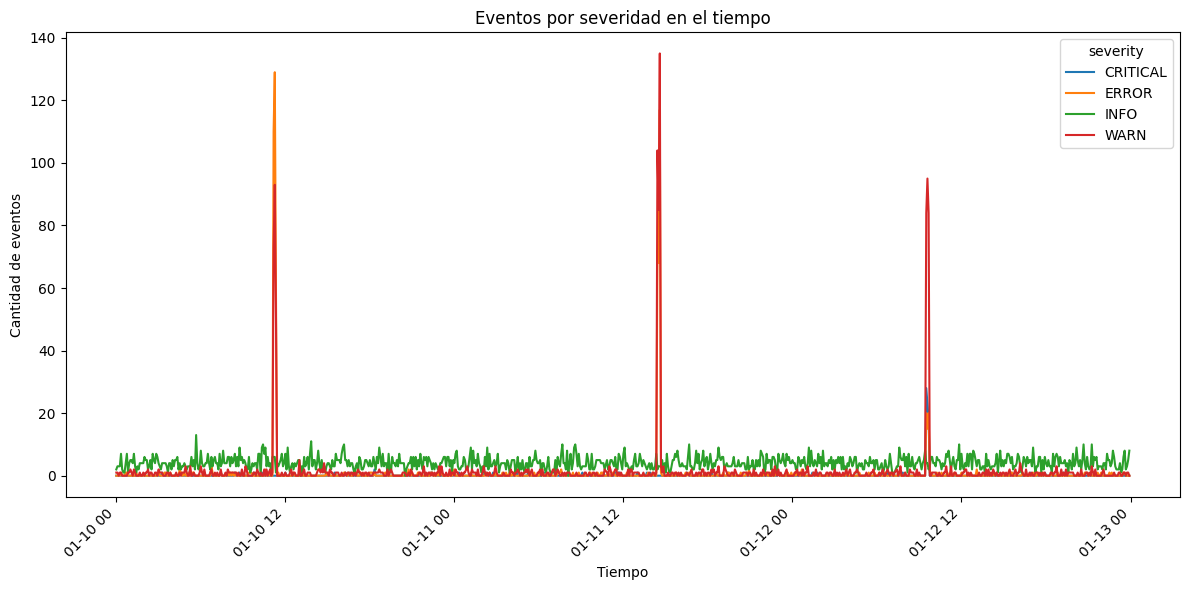

In [35]:
sev_time = df.groupby(['window', 'severity']).size().unstack(fill_value=0)

sev_time = sev_time.sort_index()

sev_time.plot(figsize=(12,6))

plt.title("Eventos por severidad en el tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

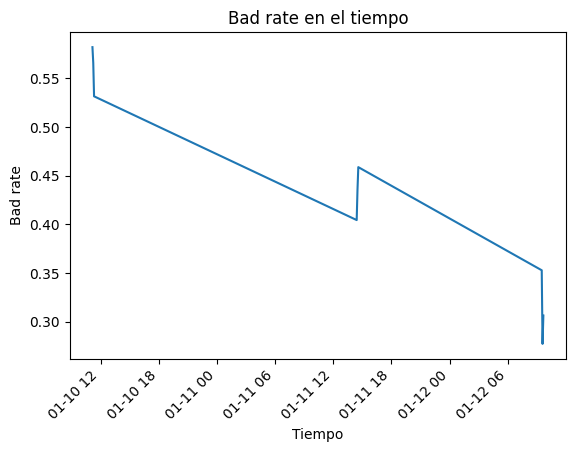

In [36]:
window_stats['bad_rate'].plot()

plt.title("Bad rate en el tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Bad rate")
plt.xticks(rotation=45)
plt.show()

## 8. Conclusión (LO MÁS IMPORTANTE)

In [37]:
critical_window = top_windows.index[0]

print(f'el momento critico ocurrio en {critical_window} donde el bad rate alcanzo su valor maximo')

el momento critico ocurrio en 2026-01-10 11:10:00+00:00 donde el bad rate alcanzo su valor maximo


In [38]:
critical_df = df[df['window'] == critical_window]
bad_by_service = critical_bad['service_name'].value_counts()


most_affected_service = bad_by_service.idxmax()

print("Servicio más afectado:", most_affected_service)

Servicio más afectado: orders-service


In [39]:

most_affected_endpoint = top_endpoints.idxmax()

print("Endpoint más comprometido:", most_affected_endpoint)

Endpoint más comprometido: /orders/cancel


In [40]:
least_active_service = df['service_name'].value_counts().idxmin()

print("serv con menos logs:" ,least_active_service)

serv con menos logs: notification-service


In [41]:
comparison

,critical,baseline
total_events,189.000000,5606.000000
bad_rate,0.582011,0.140029
avg_latency_ms,1589.687831,521.094363
%_5xx,0.582011,0.140029


In [42]:
message_counts = critical_bad['message'].value_counts()
pd.DataFrame(message_counts.head())

,count
message,
Order creation failed - inventory lock timeout,72
Database deadlock detected,37
External dependency error,1


In [43]:
window_stats.head()

,total_events,bad_events,bad_rate
window,,,
2026-01-10 11:10:00+00:00,189,110,0.582011
2026-01-10 11:15:00+00:00,228,129,0.565789
2026-01-10 11:20:00+00:00,111,59,0.531532
2026-01-11 14:25:00+00:00,178,72,0.404494
2026-01-11 14:30:00+00:00,156,68,0.435897


In [44]:
summary_df = pd.DataFrame({
    "Metric": [
        "Momento crítico",
        "Servicio más afectado",
        "Endpoint más comprometido",
        "Mensaje dominante",
        "Bad rate (baseline → crítico)",
        "Latencia promedio (baseline → crítico)"
    ],
    "Valor": [
        str(critical_window),
        most_affected_service,
        most_affected_endpoint,
        dominant_message,
        f"{baseline_bad_rate:.2f} → {critical_bad_rate:.2f}",
        f"{baseline_df['latency_ms'].mean():.0f} → {critical_df['latency_ms'].mean():.0f} ms"
    ]
})

summary_df

,Metric,Valor
0,Momento crítico,2026-01-10 11:10:00+00:00
1,Servicio más afectado,orders-service
2,Endpoint más comprometido,/orders/cancel
3,Mensaje dominante,Order creation failed - inventory lock timeout
4,Bad rate (baseline → crítico),0.15 → 0.58
5,Latencia promedio (baseline → crítico),521 → 1590 ms
